# Data Preprocessing

## Objective

Prepare the dataset for machine learning by cleaning, transforming, and encoding the data based on the insights obtained during Exploratory Data Analysis (EDA).

The objective is to convert the raw dataset into a clean, consistent, and model-ready dataset while preserving meaningful information.

---

## Questions

- How should missing values be handled?
- Which missing values represent the absence of a feature?
- Which categorical features are ordinal and which are nominal?
- Which encoding technique should be used for each categorical feature?
- Which numerical features require scaling?
- Are there skewed features that require transformation?
- Are there highly correlated features that need special consideration?
- Can new informative features be engineered from the existing features?
- Is the final dataset suitable for machine learning models?

---

## Expected Outcome

By the end of preprocessing, the dataset should:

- Contain no inappropriate missing values.
- Have categorical features encoded appropriately.
- Have numerical features transformed or scaled where necessary.
- Include any useful engineered features.
- Be clean, consistent, and ready for model training.

---

In [1]:
import pandas as pd
df=pd.read_csv('../data/train.csv')
total_rows=len(df)

## *Part A: Missing Values Handling*

## Step 1: Create a Missing Value Summary Table

In [2]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Data_Type": df.dtypes
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage,Data_Type
PoolQC,1453,99.520548,str
MiscFeature,1406,96.301370,str
Alley,1369,93.767123,str
Fence,1179,80.753425,str
MasVnrType,872,59.726027,str
FireplaceQu,690,47.260274,str
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,str
GarageYrBlt,81,5.547945,float64
GarageFinish,81,5.547945,str


## Step 2: Identify Features Where Missing Values Represent Feature Absence

### Objective

Determine whether missing values indicate that the corresponding feature is absent rather than the information being unavailable.

---

### Observation

Based on the data dictionary and EDA, several missing values occur because the corresponding feature does not exist for certain houses.

Examples include:

- Houses without a garage
- Houses without a pool
- Houses without a fireplace
- Houses without alley access
- Houses without miscellaneous features

These missing values are informative and therefore should not be treated as unknown values.

---

## Confirmed Feature-Absence Groups

### Garage Features

- GarageType
- GarageFinish
- GarageQual
- GarageCond
- GarageYrBlt

**Interpretation:** Missing values indicate that the house does not have a garage.

---

### Other Features

- PoolQC → No Pool
- FireplaceQu → No Fireplace
- Alley → No Alley Access
- Fence → No Fence
- MiscFeature → No Miscellaneous Feature


-Keeping these values as `NaN` would incorrectly imply missing information. Replacing them with `"None"` explicitly preserves the semantic meaning that the feature is absent.


---

## Features Requiring Further Investigation

Not all missing values can be directly interpreted as feature absence.

The following features require further analysis before selecting an imputation strategy.


### Basement Features

- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2

### Remaining Features

- LotFrontage
- MasVnrType
- MasVnrArea
- Electrical
  
---

In [3]:
basement_features = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[basement_features].isnull().sum()

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
dtype: int64

In [4]:
df[df["BsmtExposure"].isnull() & df["BsmtQual"].notnull()][basement_features]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
948,Gd,TA,NaN,Unf,Unf


In [5]:
df[df["BsmtFinType2"].isnull() & df["BsmtQual"].notnull()][basement_features]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
332,Gd,TA,No,GLQ,NaN


## Step 3: Investigate Basement Features

### Objective

Investigate the basement-related features with missing values to determine whether the missing values represent feature absence or data inconsistencies.

---

### Observation

The missing counts for the basement-related features were compared.

| Feature | Missing Count |
|---------|---------------:|
| BsmtQual | 37 |
| BsmtCond | 37 |
| BsmtExposure | 38 |
| BsmtFinType1 | 37 |
| BsmtFinType2 | 38 |

If the missing values were solely due to the absence of a basement, all basement-related features would have identical missing counts.

The mismatch indicates that a small number of observations require further investigation.

---

### Investigation

#### Case 1: BsmtExposure

One observation contained:

- BsmtQual = Gd
- BsmtCond = TA
- BsmtFinType1 = Unf
- BsmtFinType2 = Unf
- BsmtExposure = NaN

Since all other basement attributes were present, the house clearly has a basement.

Therefore, the missing value in `BsmtExposure` is most likely a data entry error rather than the absence of a basement.

**Decision**

Replace the missing value with `"No"`.

---

#### Case 2: BsmtFinType2

One observation contained:

- BsmtQual = Gd
- BsmtCond = TA
- BsmtExposure = No
- BsmtFinType1 = GLQ
- BsmtFinType2 = NaN

The basement exists, but there is insufficient information to infer the correct basement finish type.

Therefore, a statistical imputation method is appropriate.

**Decision**

Replace the missing value with the mode of `BsmtFinType2`.

---

In [6]:
df.loc[
    df["BsmtExposure"].isnull() & df["BsmtQual"].notnull(),
    "BsmtExposure"
] = "No"

df.loc[
    df["BsmtFinType2"].isnull() & df["BsmtQual"].notnull(),
    "BsmtFinType2"
] = df["BsmtFinType2"].mode()[0]

In [7]:
df[basement_features].isnull().sum()  #verification

BsmtQual        37
BsmtCond        37
BsmtExposure    37
BsmtFinType1    37
BsmtFinType2    37
dtype: int64

## Step 4: Investigate  MasVnrType & MasVnrArea

### Objective

Investigate the masonry veneer-related features to determine whether the missing values represent feature absence or genuine missing information.

### Observation

According to the dataset documentation:

- `MasVnrType` describes the type of masonry veneer applied to the house.
- One valid category is **"None"**, indicating that the house has **no masonry veneer**.

Since `MasVnrType` and `MasVnrArea` describe the same property, they should be investigated together before selecting an imputation strategy.

### Next Step

Verify how the dataset represents houses with **no masonry veneer** and determine whether the missing values correspond to feature absence or genuine missing data.

---

In [8]:
df["MasVnrType"].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [9]:
df.loc[
    df["MasVnrArea"].isnull(),
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


### Investigation: MasVnrType & MasVnrArea

`MasVnrType` and `MasVnrArea` were investigated together because both describe the masonry veneer of a house.

According to the data dictionary, `"None"` is a valid category for `MasVnrType`, representing houses without masonry veneer.

Inspection of the dataset showed that the `"None"` category is stored as `NaN` rather than as a string.

Furthermore, all observations with missing `MasVnrArea` also had missing `MasVnrType`, indicating that these houses do not have masonry veneer.

Therefore, these missing values represent **feature absence** rather than genuine missing information.

### Preprocessing Decision

During the missing value handling stage:

- `MasVnrType` missing values will be replaced with `"None"`.
- `MasVnrArea` missing values will be replaced with `0`.
---

In [10]:
# Houses without masonry veneer have zero masonry veneer area
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

## Step 5: Investigation: LotFrontage

### Objective

Investigate the missing values in `LotFrontage` and determine an appropriate imputation strategy.

### Questions

- Is the distribution skewed?
- Are outliers present?
- Is the median a better estimate than the mean?
- Would neighborhood-wise imputation better preserve the characteristics of different locations?

----

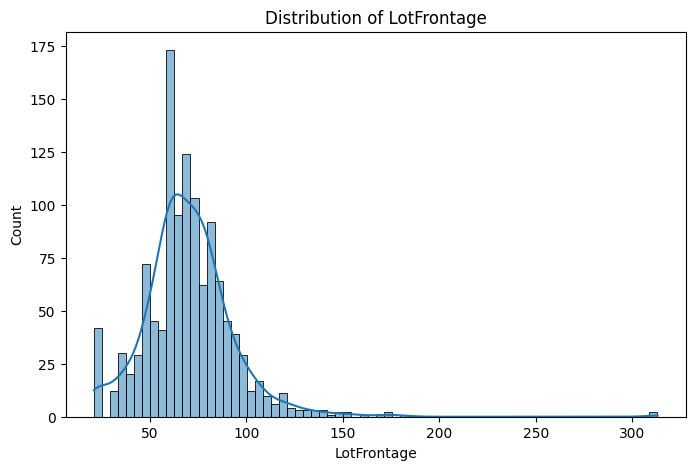

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["LotFrontage"], kde=True)

plt.title("Distribution of LotFrontage")
plt.xlabel("LotFrontage")
plt.ylabel("Count")
plt.show()

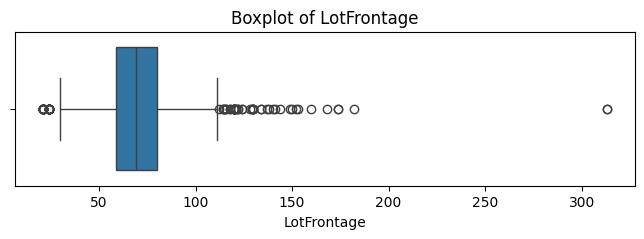

In [12]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["LotFrontage"])

plt.title("Boxplot of LotFrontage")
plt.show()

### Investigation: LotFrontage

`LotFrontage` exhibits a **right-skewed distribution** with several high-value outliers.

Since the mean is sensitive to extreme values, it is shifted toward the higher frontage values and does not accurately represent a typical house.

The **median** is more robust to outliers and provides a better estimate of the central tendency.

### Preprocessing Decision

Missing values in `LotFrontage` will be imputed using the **median** rather than the mean.

---

### Improved Imputation Strategy

Although the median is more robust than the mean for a right-skewed distribution, using a **single global median** may ignore differences between neighborhoods.

Since `LotFrontage` is strongly influenced by the location and size of the property, houses in different neighborhoods tend to have different frontage distributions.

Therefore, imputing missing values using the **median LotFrontage within each Neighborhood** better preserves the characteristics of individual neighborhoods and is expected to produce more realistic estimates.

### Preprocessing Decision

Missing values in `LotFrontage` will be imputed using the **median LotFrontage of the corresponding Neighborhood**.

---

In [13]:
df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [14]:
df["LotFrontage"] = (
    df.groupby("Neighborhood")["LotFrontage"]
      .transform(lambda x: x.fillna(x.median()))
)

## Step 6: Investigation: Electrical

### Objective

Investigate the missing value in `Electrical` to determine whether it represents feature absence or genuine missing information and decide an appropriate imputation strategy.

In [15]:
df.loc[df["Electrical"].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [16]:
df["Electrical"].value_counts(dropna=False)

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

In [28]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

### Investigation Findings

The missing value in `Electrical` represents **genuine missing information** rather than feature absence, as every house is expected to have an electrical system and the dataset description does not define a `None` category.

Only **one observation** is missing this value. Therefore, removing the entire row would unnecessarily reduce the training data.

Since the feature is categorical and one category is expected to dominate the distribution, imputing the missing value with the **mode** is an appropriate and statistically reasonable strategy.

### Preprocessing Decision

Impute the missing value in `Electrical` using the **most frequent category (mode)**.


---

## Step 9: Handle Feature Absence

### Objective

Replace missing values that represent **feature absence** with an explicit category (`"None"`).

### Rationale

During the missing value investigation, these features were identified as cases where a missing value indicates that the corresponding feature is **not applicable** rather than missing due to incomplete data collection.

Keeping these values as `NaN` would incorrectly imply missing information. Replacing them with `"None"` explicitly preserves the semantic meaning that the feature is absent.

### Preprocessing Decision

Replace missing values with `"None"` for all categorical features where `NaN` represents feature absence.

In [21]:
feature_absence = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

In [22]:
df[feature_absence] = df[feature_absence].fillna("None")

In [23]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

GarageYrBlt is missing only when a house has no garage. Since a numerical feature cannot take the categorical value "None", we use 0 as a sentinel value indicating the absence of a garage. This value is interpreted together with the garage-related categorical features, which have already been encoded as "None".

---

## Missing Value Handling Summary

### Objective

Handle missing values by distinguishing **feature absence** from **genuine missing information**, investigating ambiguous cases, and applying appropriate imputation strategies.

### Summary

- Created a missing value summary table to identify affected features.
- Categorized missing values into:
  - **Feature Absence** (e.g., no garage, no basement, no pool).
  - **Genuine Missing Values** requiring investigation.
- Investigated ambiguous basement records and corrected inconsistent entries.
- Identified missing masonry veneer values as feature absence and imputed accordingly.
- Imputed `LotFrontage` using the **Neighborhood-wise median** to preserve local characteristics.
- Imputed the single missing `Electrical` value using the **mode**.
- Replaced feature-absence categorical values with `"None"`.
- Filled `GarageYrBlt` with `0` as a sentinel value indicating the absence of a garage.

### Final Imputation Decisions

| Feature | Strategy |
|---------|----------|
| PoolQC, Alley, Fence, FireplaceQu | `"None"` |
| Garage categorical features | `"None"` |
| Basement categorical features | `"None"` |
| BsmtExposure | `"No"` (ambiguous record) |
| BsmtFinType2 | Mode (ambiguous record) |
| MasVnrType | `"None"` |
| MasVnrArea | `0` |
| LotFrontage | Neighborhood-wise median |
| Electrical | Mode (`SBrkr`) |
| GarageYrBlt | `0` |

### Conclusion

Missing values were handled using **dataset documentation, EDA findings, statistical reasoning, and domain knowledge**. This ensured that feature absence and genuine missing information were treated appropriately while preserving the integrity of the dataset.

In [29]:
verification = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

verification[verification["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage


-------------------------------